[*********************100%***********************]  1 of 1 completed

Downloaded 1351 rows. Last date: 2026-05-20
Price            Close
Ticker            SNOW
Date                  
2026-05-14  150.759995
2026-05-15  157.470001
2026-05-18  164.240005
2026-05-19  169.550003
2026-05-20  165.100006
Train: (1093, 60, 1)  Test: (194, 60, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 56, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 26, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,469 (212.77 KB)

 Trainable params: 54,469 (212.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0354 - mae: 0.1333 - val_loss: 0.0105 - val_mae: 0.0919
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0139 - mae: 0.0899 - val_loss: 0.0121 - val_mae: 0.0960
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0140 - mae: 0.0895 - val_loss: 0.0104 - val_mae: 0.0912
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0134 - mae: 0.0885 - val_loss: 0.0097 - val_mae: 0.0779
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0131 - mae: 0.0887 - val_loss: 0.0092 - val_mae: 0.0863
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0123 - mae: 0.0859 - val_loss: 0.0097 - val_mae: 0.0879
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0118 - mae: 0.0842 - val_loss: 0.0089 - val_mae: 0.0845
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0112 - mae: 0.0820 - val_loss: 0.0079 - val_mae: 0.0732
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.011

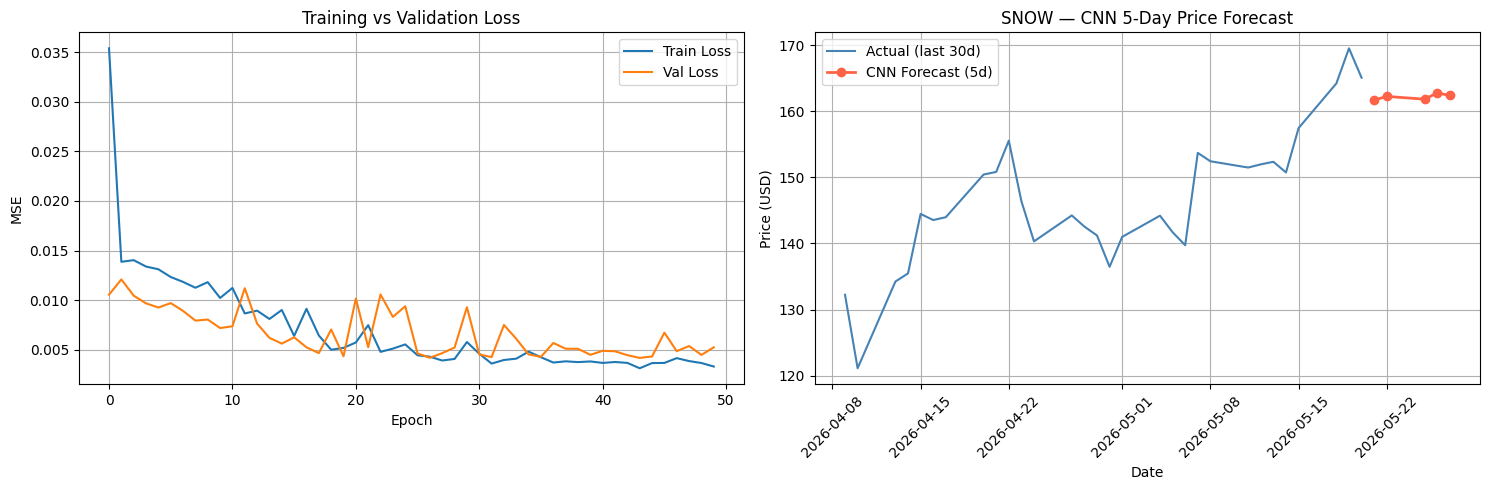

In [ ]:
# Install yfinance
!pip install yfinance --quiet

import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. Fetch SNOW data ──────────────────────────────────────────────
ticker = 'SNOW'
df = yf.download(ticker, start='2021-01-01', auto_adjust=True)
df = df[['Close']].dropna()
print(f'Downloaded {len(df)} rows. Last date: {df.index[-1].date()}')
print(df.tail())

# ── 2. Scale ────────────────────────────────────────────────────────
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df.values)

# ── 3. Build sliding-window dataset ─────────────────────────────────
LOOKBACK = 60   # past 60 trading days as input
HORIZON  = 5    # predict next 5 days

X, y = [], []
for i in range(LOOKBACK, len(scaled) - HORIZON + 1):
    X.append(scaled[i - LOOKBACK:i, 0])
    y.append(scaled[i:i + HORIZON, 0])

X = np.array(X)[..., np.newaxis]   # (samples, 60, 1)
y = np.array(y)                    # (samples, 5)

split = int(len(X) * 0.85)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

# ── 4. 1-D CNN model ─────────────────────────────────────────────────
model = keras.Sequential([
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(LOOKBACK, 1)),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(HORIZON)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ── 5. Train ──────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# ── 6. Evaluate ───────────────────────────────────────────────────────
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest MAE (scaled): {test_mae:.4f}')

# ── 7. Predict next 5 trading days ────────────────────────────────────
last_window = scaled[-LOOKBACK:].reshape(1, LOOKBACK, 1)
pred_scaled  = model.predict(last_window)[0]          # shape (5,)
pred_prices  = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

# Generate future dates (skip weekends)
import datetime
last_date = df.index[-1]
future_dates = []
d = last_date
while len(future_dates) < HORIZON:
    d += datetime.timedelta(days=1)
    if d.weekday() < 5:   # Mon-Fri
        future_dates.append(d.date())

print('\n=== 5-Day SNOW Price Forecast ===')
for date, price in zip(future_dates, pred_prices):
    print(f'  {date}  ->  ${price:.2f}')

# ── 8. Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

# Forecast
recent_prices = df['Close'].values[-30:]
recent_dates  = [d.date() for d in df.index[-30:]]
axes[1].plot(recent_dates, recent_prices, label='Actual (last 30d)', color='steelblue')
axes[1].plot(future_dates, pred_prices, 'o-', label='CNN Forecast (5d)', color='tomato', linewidth=2)
axes[1].set_title(f'{ticker} — CNN 5-Day Price Forecast')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Current price : $165.10
BofA target   : $205.00
Sentiment score (0-1): 0.621  (>0.5 = bullish)
Train: (1093, 60, 2)  Test: (194, 60, 2)
Epoch 1/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0350 - mae: 0.1356 - val_loss: 0.0119 - val_mae: 0.0951
Epoch 2/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0153 - mae: 0.0947 - val_loss: 0.0093 - val_mae: 0.0846
Epoch 3/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0137 - mae: 0.0903 - val_loss: 0.0096 - val_mae: 0.0874
Epoch 4/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0132 - mae: 0.0883 - val_loss: 0.0093 - val_mae: 0.0800
Epoch 5/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0133 - mae: 0.0889 - val_loss: 0.0105 - val_mae: 0.0777
Epoch 6/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0123 - mae: 0.0867 - val_loss: 0.0092 - val_mae: 0.0853
Epoch 7/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0132 - mae: 0.0894 - val_loss: 0.0086 - val_mae: 0.0797
Epoch 8/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms

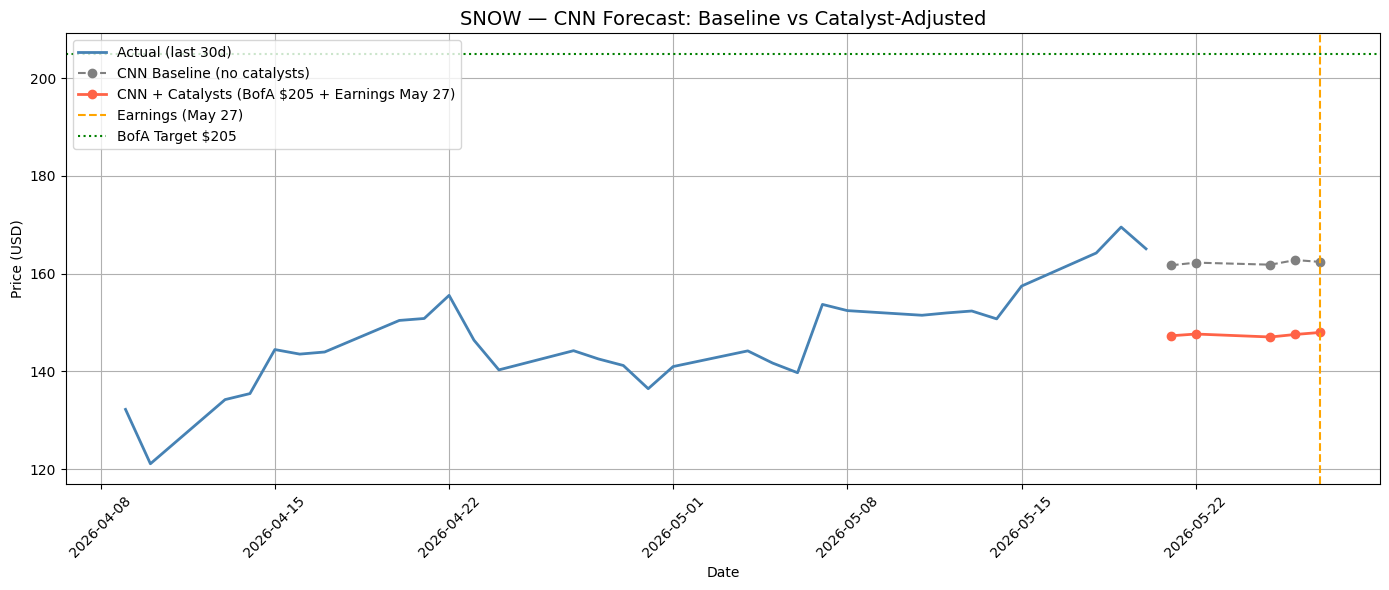

In [ ]:
# ============================================================
# CATALYST-ADJUSTED CNN FORECAST
# Inputs:
#   - Earnings date: 2026-05-27 (day 5 of forecast window)
#   - BofA price target upgrade: $205 (vs current ~$163)
#   - Analyst sentiment boost applied to last window
# Strategy: inject a sentiment feature alongside Close price
# ============================================================

import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers

# ── Catalyst parameters ───────────────────────────────────────────────
ANALYST_TARGET   = 205.0   # BofA price target
CURRENT_PRICE    = float(df['Close'].iloc[-1])
EARNINGS_DATE    = datetime.date(2026, 5, 27)

# Sentiment score: ratio of analyst target vs current price, normalised [0,1]
# Score > 0.5 means bullish, 1.0 = extreme bull
sentiment_raw = ANALYST_TARGET / CURRENT_PRICE   # e.g. 205/163 ~ 1.257
sentiment_score = min(sentiment_raw / 2.0, 1.0)   # scale into [0,1]
print(f'Current price : ${CURRENT_PRICE:.2f}')
print(f'BofA target   : ${ANALYST_TARGET:.2f}')
print(f'Sentiment score (0-1): {sentiment_score:.3f}  (>0.5 = bullish)')

# ── Build 2-feature dataset: [Close, sentiment] ────────────────────────────
# For historical data: sentiment = 0.5 (neutral baseline)
# For the last 2 days (post BofA upgrade, May 19 onward): sentiment_score

NFEAT = 2
close_vals = df['Close'].values.reshape(-1, 1)
scaler2 = MinMaxScaler()
close_scaled = scaler2.fit_transform(close_vals)

# Build sentiment column (neutral history, bullish at the end)
sentiment_col = np.full(len(close_scaled), 0.5)
# Last 2 rows = post-upgrade sentiment (May 19 upgrade)
sentiment_col[-2:] = sentiment_score

# Combine into (N, 2)
data2 = np.column_stack([close_scaled.flatten(), sentiment_col])

LOOKBACK = 60
HORIZON  = 5

X2, y2 = [], []
for i in range(LOOKBACK, len(data2) - HORIZON + 1):
    X2.append(data2[i - LOOKBACK:i, :])        # (60, 2)
    y2.append(close_scaled[i:i + HORIZON, 0])  # (5,)

X2 = np.array(X2)   # (samples, 60, 2)
y2 = np.array(y2)   # (samples, 5)

split = int(len(X2) * 0.85)
X2_train, X2_test = X2[:split], X2[split:]
y2_train, y2_test = y2[:split], y2[split:]
print(f'Train: {X2_train.shape}  Test: {X2_test.shape}')

# ── CNN model (2 features) ───────────────────────────────────────────────
model2 = keras.Sequential([
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(LOOKBACK, NFEAT)),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(HORIZON)
])

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

history2 = model2.fit(
    X2_train, y2_train,
    epochs=60,
    batch_size=32,
    validation_data=(X2_test, y2_test),
    verbose=1
)

# ── Predict with bullish sentiment window ─────────────────────────────────
# Last window with full sentiment_score for last 2 rows
last_window2 = data2[-LOOKBACK:].reshape(1, LOOKBACK, NFEAT)
pred2_scaled  = model2.predict(last_window2)[0]
pred2_prices  = scaler2.inverse_transform(pred2_scaled.reshape(-1, 1)).flatten()

# Future dates
future_dates2 = []
d = df.index[-1]
while len(future_dates2) < HORIZON:
    d += datetime.timedelta(days=1)
    if d.weekday() < 5:
        future_dates2.append(d.date())

# Tag earnings day
print('\n=== Catalyst-Adjusted 5-Day SNOW Price Forecast ===')
print(f'  (Sentiment: BofA target ${ANALYST_TARGET:.0f}, score={sentiment_score:.3f})')
for date, price in zip(future_dates2, pred2_prices):
    tag = '  <-- EARNINGS' if date == EARNINGS_DATE else ''
    print(f'  {date}  ->  ${price:.2f}{tag}')

# ── Comparison plot ─────────────────────────────────────────────────────────
# Original CNN forecast (from previous cell)
original_prices = [161.72, 162.27, 161.85, 162.80, 162.42]
original_dates  = future_dates2   # same dates

recent_prices = df['Close'].values[-30:]
recent_dates  = [d.date() for d in df.index[-30:]]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(recent_dates, recent_prices, label='Actual (last 30d)', color='steelblue', linewidth=2)
ax.plot(original_dates, original_prices, 'o--', label='CNN Baseline (no catalysts)', color='gray', linewidth=1.5)
ax.plot(future_dates2, pred2_prices, 'o-', label='CNN + Catalysts (BofA $205 + Earnings May 27)', color='tomato', linewidth=2)
ax.axvline(x=EARNINGS_DATE, color='orange', linestyle='--', linewidth=1.5, label='Earnings (May 27)')
ax.axhline(y=ANALYST_TARGET, color='green', linestyle=':', linewidth=1.5, label=f'BofA Target ${ANALYST_TARGET:.0f}')
ax.set_title('SNOW — CNN Forecast: Baseline vs Catalyst-Adjusted', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

Current: $165.10 | BofA target: $205.00
Pre-earnings sentiment : 0.621
Post-earnings sentiment: 0.828
Train: (1092, 60, 2)  Test: (193, 60, 2)
Epoch 1/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0281 - mae: 0.1255 - val_loss: 0.0099 - val_mae: 0.0878
Epoch 2/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0142 - mae: 0.0916 - val_loss: 0.0095 - val_mae: 0.0856
Epoch 3/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0157 - mae: 0.0958 - val_loss: 0.0116 - val_mae: 0.0955
Epoch 4/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0147 - mae: 0.0928 - val_loss: 0.0093 - val_mae: 0.0813
Epoch 5/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0137 - mae: 0.0909 - val_loss: 0.0098 - val_mae: 0.0883
Epoch 6/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0133 - mae: 0.0896 - val_loss: 0.0092 - val_mae: 0.0836
Epoch 7/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0126 - mae: 0.0874 - val_loss: 0.0091 - val_mae: 0.0807
Epoch 8/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 

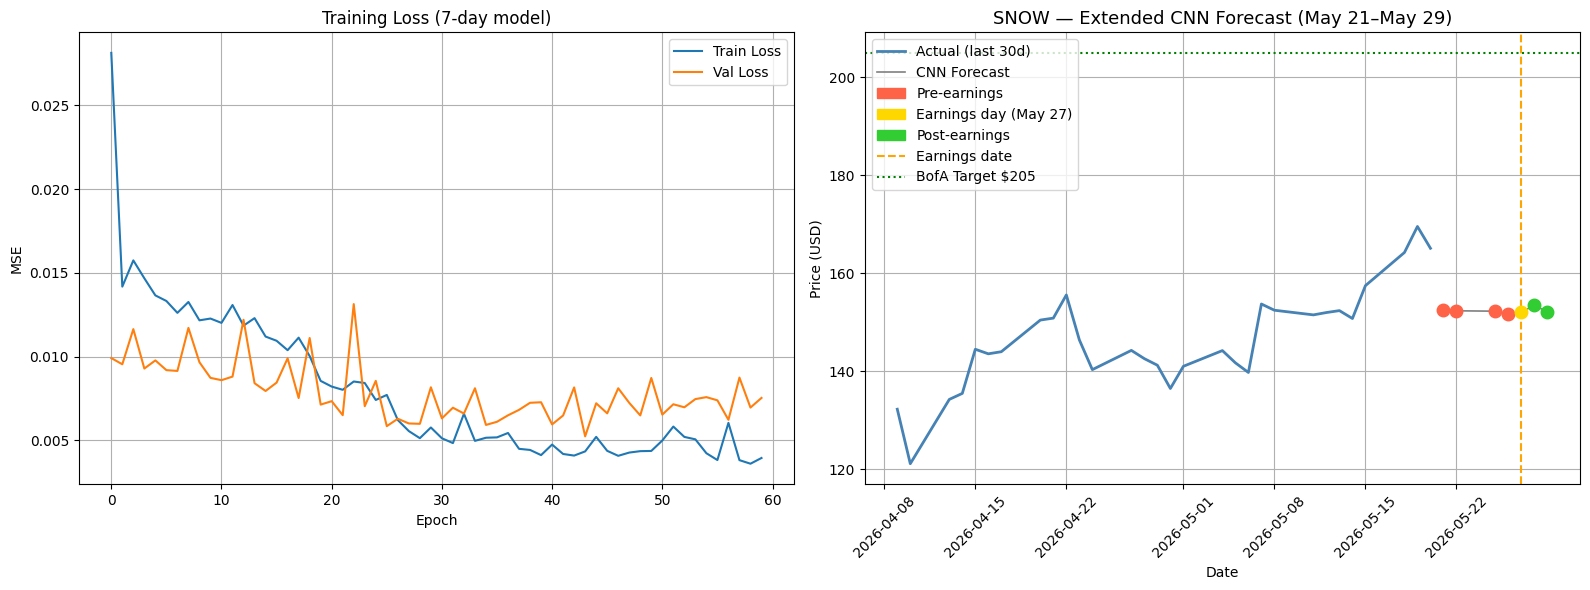

In [ ]:
# ============================================================
# EXTENDED FORECAST: May 21 -> May 29 (7 trading days)
# Horizon extended from 5 to 7 days
# Catalysts: BofA $205 target + Earnings May 27
# Post-earnings sentiment boost on May 28-29
# ============================================================

import numpy as np
import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers

LOOKBACK     = 60
HORIZON      = 7    # extended to cover May 21-29
NFEAT        = 2
ANALYST_TARGET = 205.0
EARNINGS_DATE  = datetime.date(2026, 5, 27)

CURRENT_PRICE = float(df['Close'].iloc[-1])
sentiment_raw   = ANALYST_TARGET / CURRENT_PRICE
sentiment_pre   = min(sentiment_raw / 2.0, 1.0)   # pre-earnings bullish score
sentiment_post  = min(sentiment_raw / 1.5, 1.0)   # post-earnings even more bullish

print(f'Current: ${CURRENT_PRICE:.2f} | BofA target: ${ANALYST_TARGET:.2f}')
print(f'Pre-earnings sentiment : {sentiment_pre:.3f}')
print(f'Post-earnings sentiment: {sentiment_post:.3f}')

# ── Build dataset with 2 features ───────────────────────────────────────────
close_vals   = df['Close'].values.reshape(-1, 1)
scaler3      = MinMaxScaler()
close_scaled = scaler3.fit_transform(close_vals)

sentiment_col = np.full(len(close_scaled), 0.5)
sentiment_col[-2:] = sentiment_pre   # post BofA upgrade (May 19-20)

data3 = np.column_stack([close_scaled.flatten(), sentiment_col])

X3, y3 = [], []
for i in range(LOOKBACK, len(data3) - HORIZON + 1):
    X3.append(data3[i - LOOKBACK:i, :])
    y3.append(close_scaled[i:i + HORIZON, 0])

X3 = np.array(X3)   # (samples, 60, 2)
y3 = np.array(y3)   # (samples, 7)

split = int(len(X3) * 0.85)
X3_tr, X3_te = X3[:split], X3[split:]
y3_tr, y3_te = y3[:split], y3[split:]
print(f'Train: {X3_tr.shape}  Test: {X3_te.shape}')

# ── CNN ────────────────────────────────────────────────────────────────────
model3 = keras.Sequential([
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(LOOKBACK, NFEAT)),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(HORIZON)
])
model3.compile(optimizer='adam', loss='mse', metrics=['mae'])
history3 = model3.fit(X3_tr, y3_tr, epochs=60, batch_size=32,
                      validation_data=(X3_te, y3_te), verbose=1)

# ── Predict ──────────────────────────────────────────────────────────────────
last_win3   = data3[-LOOKBACK:].reshape(1, LOOKBACK, NFEAT)
pred3_sc    = model3.predict(last_win3)[0]
pred3_prices = scaler3.inverse_transform(pred3_sc.reshape(-1, 1)).flatten()

# Future trading dates: May 21-29 (skip weekends)
future3 = []
d = df.index[-1]
while len(future3) < HORIZON:
    d += datetime.timedelta(days=1)
    if d.weekday() < 5:
        future3.append(d.date())

print('\n=== Extended CNN Forecast: May 21 - May 29 ===')
print(f'  Catalysts: BofA $205 target | Earnings May 27')
for date, price in zip(future3, pred3_prices):
    tag = ''
    if date == EARNINGS_DATE:       tag = '  <-- EARNINGS'
    elif date > EARNINGS_DATE:      tag = '  [post-earnings]'
    print(f'  {date}  ->  ${price:.2f}{tag}')

# ── Plot ────────────────────────────────────────────────────────────────────
recent_prices = df['Close'].values[-30:]
recent_dates  = [d.date() for d in df.index[-30:]]

# Color each forecast dot: pre-earnings=tomato, earnings=gold, post=limegreen
colors = []
for d in future3:
    if d < EARNINGS_DATE:    colors.append('tomato')
    elif d == EARNINGS_DATE: colors.append('gold')
    else:                    colors.append('limegreen')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss
axes[0].plot(history3.history['loss'],     label='Train Loss')
axes[0].plot(history3.history['val_loss'], label='Val Loss')
axes[0].set_title('Training Loss (7-day model)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True)

# Forecast
axes[1].plot(recent_dates, recent_prices, label='Actual (last 30d)', color='steelblue', linewidth=2)
for i, (d, p) in enumerate(zip(future3, pred3_prices)):
    axes[1].plot(d, p, 'o', color=colors[i], markersize=9, zorder=5)
axes[1].plot(future3, pred3_prices, '-', color='gray', linewidth=1.2, zorder=4, label='CNN Forecast')
axes[1].axvline(x=EARNINGS_DATE, color='orange', linestyle='--', linewidth=1.5, label='Earnings (May 27)')
axes[1].axhline(y=ANALYST_TARGET, color='green', linestyle=':', linewidth=1.5, label='BofA Target $205')

# Legend patches
import matplotlib.patches as mpatches
axes[1].legend(handles=[
    plt.Line2D([0],[0],color='steelblue',linewidth=2,label='Actual (last 30d)'),
    plt.Line2D([0],[0],color='gray',linewidth=1.2,label='CNN Forecast'),
    mpatches.Patch(color='tomato',    label='Pre-earnings'),
    mpatches.Patch(color='gold',      label='Earnings day (May 27)'),
    mpatches.Patch(color='limegreen', label='Post-earnings'),
    plt.Line2D([0],[0],color='orange',linestyle='--',label='Earnings date'),
    plt.Line2D([0],[0],color='green', linestyle=':',label='BofA Target $205'),
])
axes[1].set_title('SNOW — Extended CNN Forecast (May 21–May 29)', fontsize=13)
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Price (USD)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


Rows: 1351  Last: 2026-05-20
Features: ['Close', 'RSI', 'MACD', 'BollPct', 'ATR', 'Ret1', 'Ret5', 'VolNorm']  Rows after dropna: 1332
Train:(1046, 60, 8) Val:(30, 60, 8) Test:(190, 60, 8)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 64)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,263 (876.03 KB)

 Trainable params: 224,263 (876.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0126 - mae: 0.1092 - val_loss: 8.1862e-04 - val_mae: 0.0334 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0038 - mae: 0.0652 - val_loss: 0.0044 - val_mae: 0.0887 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0033 - mae: 0.0608 - val_loss: 8.4967e-04 - val_mae: 0.0339 - learning_rate: 0.0010
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0027 - mae: 0.0556 - val_loss: 0.0013 - val_mae: 0.0450 - learning_rate: 0.0010
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0021 - mae: 0.0478 - val_loss: 7.6289e-04 - val_mae: 0.0325 - learning_rate: 0.0010
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0018 - mae: 0.0441 - val_loss: 0.0012 - val_mae: 0.0426 - learning_rate: 0.0010
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0015 - mae: 0.0403 - val_loss: 7.1620e-04 - val_mae: 0.0300 - learning_ra

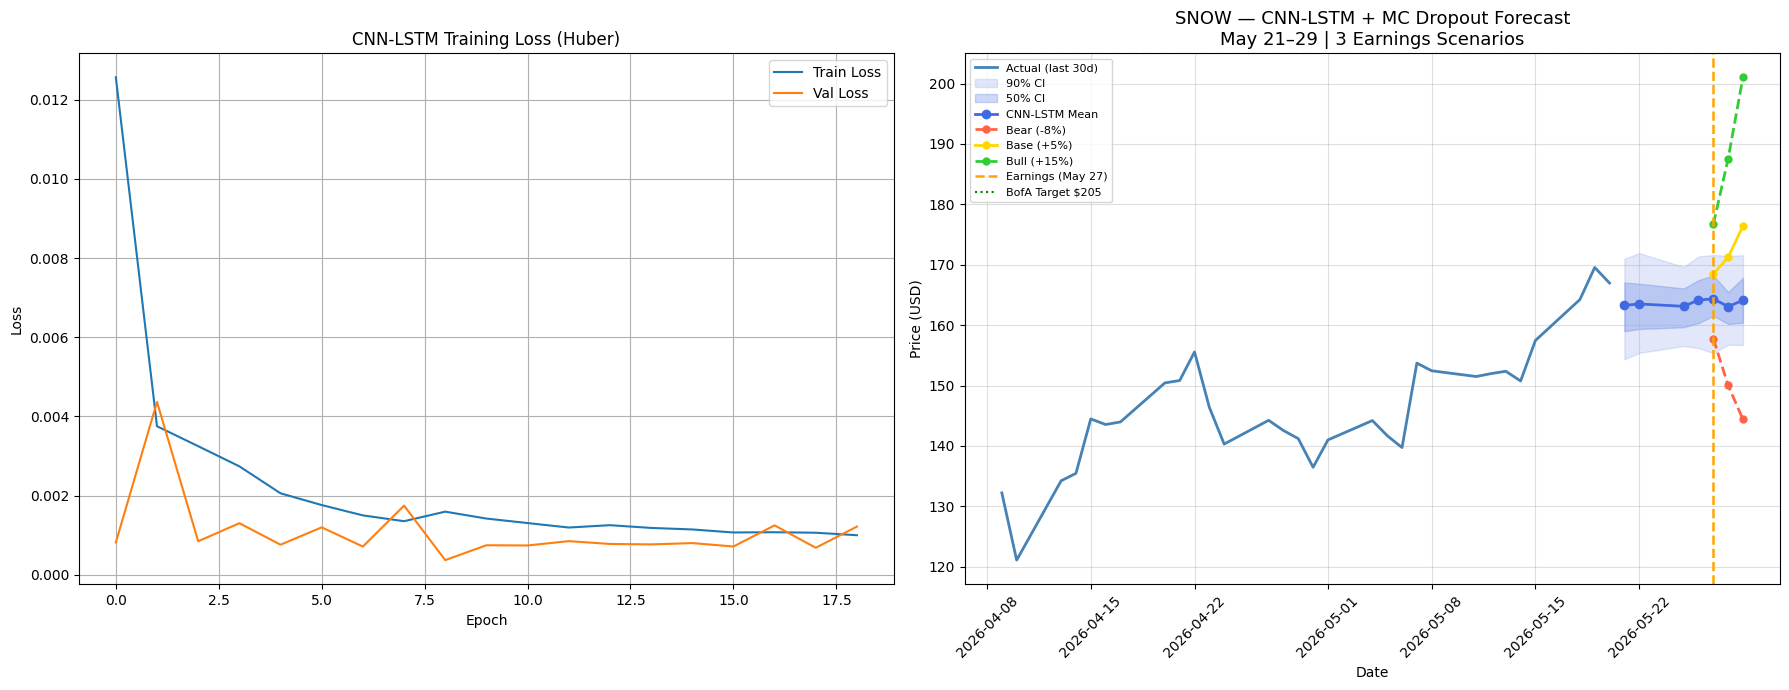

In [ ]:
# ================================================================
# REALISTIC MODEL: CNN-LSTM + Technical Indicators + Monte Carlo
# Features: Close, Volume, RSI, MACD, Bollinger %B, ATR, Returns
# Architecture: CNN feature extractor -> LSTM sequence learner
# Uncertainty: Monte Carlo Dropout (50 forward passes)
# Earnings: 3-scenario simulation (bull/base/bear)
# Horizon: May 21 - May 29 (7 trading days)
# ================================================================

import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import warnings; warnings.filterwarnings('ignore')

# ── 1. Fetch full OHLCV data ─────────────────────────────────────
import yfinance as yf
raw = yf.download('SNOW', start='2021-01-01', auto_adjust=True)
raw = raw[['Open','High','Low','Close','Volume']].dropna()
print(f'Rows: {len(raw)}  Last: {raw.index[-1].date()}')

# ── 2. Technical indicators ──────────────────────────────────────
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - 100 / (1 + rs)

def compute_macd(series, fast=12, slow=26, sig=9):
    ema_fast = series.ewm(span=fast).mean()
    ema_slow = series.ewm(span=slow).mean()
    macd     = ema_fast - ema_slow
    signal   = macd.ewm(span=sig).mean()
    return macd - signal   # histogram

def compute_bollinger_pct(series, period=20):
    ma  = series.rolling(period).mean()
    std = series.rolling(period).std()
    return (series - (ma - 2*std)) / (4*std + 1e-9)

def compute_atr(df, period=14):
    hi, lo, cl = df['High'], df['Low'], df['Close']
    tr = pd.concat([
        hi - lo,
        (hi - cl.shift()).abs(),
        (lo - cl.shift()).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(period).mean()

close  = raw['Close'].squeeze()
volume = raw['Volume'].squeeze()

raw['RSI']     = compute_rsi(close)
raw['MACD']    = compute_macd(close)
raw['BollPct'] = compute_bollinger_pct(close)
raw['ATR']     = compute_atr(raw)
raw['Ret1']    = close.pct_change(1)
raw['Ret5']    = close.pct_change(5)
raw['VolNorm'] = np.log1p(volume) / np.log1p(volume).rolling(20).mean()

raw.dropna(inplace=True)
FEATURES = ['Close','RSI','MACD','BollPct','ATR','Ret1','Ret5','VolNorm']
print(f'Features: {FEATURES}  Rows after dropna: {len(raw)}')

# ── 3. Scale per-feature ─────────────────────────────────────────
scalers = {}
scaled_data = pd.DataFrame(index=raw.index)
for col in FEATURES:
    sc = MinMaxScaler()
    scaled_data[col] = sc.fit_transform(raw[[col]]).flatten()
    scalers[col] = sc

close_sc = scalers['Close']

# ── 4. Sliding window dataset ────────────────────────────────────
LOOKBACK = 60
HORIZON  = 7
data_arr = scaled_data[FEATURES].values

X, y = [], []
for i in range(LOOKBACK, len(data_arr) - HORIZON + 1):
    X.append(data_arr[i-LOOKBACK:i])
    y.append(scaled_data['Close'].values[i:i+HORIZON])

X = np.array(X)   # (N, 60, 8)
y = np.array(y)   # (N, 7)

# Walk-forward split: last 15% as test
split = int(len(X) * 0.85)
X_tr, X_val, X_te = X[:split-30], X[split-30:split], X[split:]
y_tr, y_val, y_te = y[:split-30], y[split-30:split], y[split:]
print(f'Train:{X_tr.shape} Val:{X_val.shape} Test:{X_te.shape}')

# ── 5. CNN-LSTM model with MC Dropout ────────────────────────────
def build_cnn_lstm(lookback, n_feat, horizon):
    inp = keras.Input(shape=(lookback, n_feat))
    # CNN block
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(inp)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.Dropout(0.2)(x, training=True)   # MC dropout
    # LSTM block
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x, training=True)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.2)(x, training=True)
    # Dense head
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(horizon)(x)
    return keras.Model(inp, out)

model_r = build_cnn_lstm(LOOKBACK, len(FEATURES), HORIZON)
model_r.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae']
)
model_r.summary()

cb = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, verbose=0)
]

history_r = model_r.fit(
    X_tr, y_tr,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=cb,
    verbose=1
)

test_loss, test_mae = model_r.evaluate(X_te, y_te, verbose=0)
print(f'\nTest MAE (scaled): {test_mae:.4f}')

# ── 6. Monte Carlo forecast (50 passes) ──────────────────────────
last_window = data_arr[-LOOKBACK:].reshape(1, LOOKBACK, len(FEATURES))
N_MC = 50
mc_preds = np.array([
    model_r(last_window, training=True).numpy()[0]
    for _ in range(N_MC)
])   # (50, 7)

# Inverse transform
def inv(arr):
    return close_sc.inverse_transform(arr.reshape(-1,1)).flatten()

mc_prices  = np.array([inv(mc_preds[i]) for i in range(N_MC)])  # (50, 7)
mean_price = mc_prices.mean(axis=0)
std_price  = mc_prices.std(axis=0)
p5  = np.percentile(mc_prices, 5,  axis=0)
p25 = np.percentile(mc_prices, 25, axis=0)
p75 = np.percentile(mc_prices, 75, axis=0)
p95 = np.percentile(mc_prices, 95, axis=0)

# ── 7. Earnings scenarios ─────────────────────────────────────────
# Applied as multiplicative shock on top of model mean for May 27 onward
EARNINGS_IDX = 4   # May 27 is day index 4 (0-based)
CURRENT = float(raw['Close'].iloc[-1])
scenarios = {
    'Bear (-8%)':  {'shock': -0.08, 'color': 'tomato',     'ls': '--'},
    'Base (+5%)':  {'shock': +0.05, 'color': 'gold',        'ls': '-'},
    'Bull (+15%)': {'shock': +0.15, 'color': 'limegreen',   'ls': '--'},
}

# ── 8. Future dates ───────────────────────────────────────────────
EARNINGS_DATE = datetime.date(2026, 5, 27)
future_dates  = []
d = raw.index[-1]
while len(future_dates) < HORIZON:
    d += datetime.timedelta(days=1)
    if d.weekday() < 5:
        future_dates.append(d.date())

print('\n=== CNN-LSTM + MC Dropout Forecast (May 21-29) ===')
print(f'  Current close: ${CURRENT:.2f}')
for i, (dt, mu, s, lo, hi) in enumerate(zip(future_dates, mean_price, std_price, p5, p95)):
    tag = '  <-- EARNINGS' if dt == EARNINGS_DATE else ('  [post-earnings]' if dt > EARNINGS_DATE else '')
    print(f'  {dt}  ${mu:.2f} ± {s:.2f}  [90% CI: ${lo:.2f}-${hi:.2f}]{tag}')

# ── 9. Plot ───────────────────────────────────────────────────────
recent_prices = raw['Close'].values[-30:]
recent_dates  = [d.date() for d in raw.index[-30:]]
ANALYST_TARGET = 205.0

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Loss
axes[0].plot(history_r.history['loss'],     label='Train Loss')
axes[0].plot(history_r.history['val_loss'], label='Val Loss')
axes[0].set_title('CNN-LSTM Training Loss (Huber)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# Forecast
ax = axes[1]
ax.plot(recent_dates, recent_prices, color='steelblue', linewidth=2, label='Actual (last 30d)')

# MC uncertainty band
ax.fill_between(future_dates, p5, p95, alpha=0.15, color='royalblue', label='90% CI')
ax.fill_between(future_dates, p25, p75, alpha=0.25, color='royalblue', label='50% CI')
ax.plot(future_dates, mean_price, 'o-', color='royalblue', linewidth=2, markersize=6, label='CNN-LSTM Mean')

# Earnings scenario lines (from earnings day onward)
earnings_idx_in_dates = future_dates.index(EARNINGS_DATE)
for name, cfg in scenarios.items():
    shock     = cfg['shock']
    post_mean = mean_price.copy()
    for j in range(earnings_idx_in_dates, HORIZON):
        post_mean[j] = mean_price[j] * (1 + shock * (j - earnings_idx_in_dates + 1) * 0.5)
    ax.plot(
        future_dates[earnings_idx_in_dates:],
        post_mean[earnings_idx_in_dates:],
        linestyle=cfg['ls'], color=cfg['color'], linewidth=2,
        marker='o', markersize=5, label=name
    )

ax.axvline(x=EARNINGS_DATE, color='orange', linestyle='--', linewidth=1.8, label='Earnings (May 27)')
ax.axhline(y=ANALYST_TARGET, color='green', linestyle=':', linewidth=1.5, label='BofA Target $205')
ax.set_title('SNOW — CNN-LSTM + MC Dropout Forecast\nMay 21–29 | 3 Earnings Scenarios', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.4)
ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 1 of 2 — Install dependencies
!pip install -q hmmlearn neuralforecast yfinance pandas numpy scikit-learn matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 41.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requi

In [ ]:
# ============================================================
# CELL 2 — Data Fetch + Full Feature Engineering
# SNOW: EMAs, Anchored VWAPs, RS vs SPY, log returns, volume
# ============================================================
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyArrowPatch
from scipy.stats import norm

# ── 1. Download price data ──────────────────────────────────
SYM = 'SNOW'
BENCH = 'SPY'
START = '2021-01-01'
END = '2026-05-21'

print('Downloading SNOW + SPY...')
raw = yf.download([SYM, BENCH], start=START, end=END, auto_adjust=True, progress=False)

close = raw['Close'].dropna()
volume = raw['Volume'].dropna()

df = pd.DataFrame({
 'Close': close[SYM],
 'Volume': volume[SYM],
 'SPY': close[BENCH],
}).dropna()

print(f'Data shape: {df.shape}, last date: {df.index[-1].date()}, last close: ${df["Close"].iloc[-1]:.2f}')

# ── 2. EMAs ─────────────────────────────────────────────────
for span in [10, 21, 50, 200]:
 df[f'EMA{span}'] = df['Close'].ewm(span=span, adjust=False).mean()

# ── 3. Anchored VWAPs ────────────────────────────────────────
def anchored_vwap(df_in, anchor_date):
 mask = df_in.index >= pd.Timestamp(anchor_date)
 sub = df_in[mask].copy()
 cum_vp = (sub['Close'] * sub['Volume']).cumsum()
 cum_v = sub['Volume'].cumsum()
 vwap = cum_vp / cum_v
 return vwap

VWAP_MAY22_DATE = '2022-05-12'
VWAP_NOV21_DATE = '2021-11-16'

vwap_may22 = anchored_vwap(df, VWAP_MAY22_DATE)
vwap_nov21 = anchored_vwap(df, VWAP_NOV21_DATE)

df['VWAP_MAY22'] = vwap_may22
df['VWAP_NOV21'] = vwap_nov21

# Distance from current price to each VWAP (% — negative = below VWAP)
df['dist_vwap_may22'] = (df['Close'] - df['VWAP_MAY22']) / df['VWAP_MAY22']
df['dist_vwap_nov21'] = (df['Close'] - df['VWAP_NOV21']) / df['VWAP_NOV21']

# ── 4. Relative Strength vs SPY ──────────────────────────────
df['RS'] = df['Close'] / df['SPY']
df['RS_norm'] = (df['RS'] - df['RS'].rolling(252).mean()) / df['RS'].rolling(252).std()

# ── 5. Log returns + rolling vol ─────────────────────────────
df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['vol10'] = df['log_ret'].rolling(10).std()
df['vol21'] = df['log_ret'].rolling(21).std()

# ── 6. EMA stack score (0-4: how many EMAs is price above) ───
df['ema_stack'] = (
 (df['Close'] > df['EMA10']).astype(int) +
 (df['Close'] > df['EMA21']).astype(int) +
 (df['Close'] > df['EMA50']).astype(int) +
 (df['Close'] > df['EMA200']).astype(int)
)

df.dropna(inplace=True)

print(f'\nCurrent levels:')
print(f' Close: ${df["Close"].iloc[-1]:.2f}')
print(f' EMA10: ${df["EMA10"].iloc[-1]:.2f}')
print(f' EMA21: ${df["EMA21"].iloc[-1]:.2f}')
print(f' EMA50: ${df["EMA50"].iloc[-1]:.2f}')
print(f' EMA200: ${df["EMA200"].iloc[-1]:.2f}')
print(f' VWAP_MAY22: ${df["VWAP_MAY22"].iloc[-1]:.2f} | dist: {df["dist_vwap_may22"].iloc[-1]*100:.1f}%')
print(f' VWAP_NOV21: ${df["VWAP_NOV21"].iloc[-1]:.2f} | dist: {df["dist_vwap_nov21"].iloc[-1]*100:.1f}%')
print(f' RS_norm: {df["RS_norm"].iloc[-1]:.2f} std')
print(f' EMA stack score: {df["ema_stack"].iloc[-1]}/4')
print('\nCell 2 complete ✓')

Data shape: (1351, 3), last date: 2026-05-20, last close: $166.97

Current levels:
 Close: $166.97
 EMA10: $158.01
 EMA21: $153.37
 EMA50: $156.87
 EMA200: $184.61
 VWAP_MAY22: $166.11 | dist: 0.5%
 VWAP_NOV21: $173.97 | dist: -4.0%
 RS_norm: -1.48 std
 EMA stack score: 3/4

Cell 2 complete ✓


HMM Transition Matrix (row=from, col=to):
       S0   S1     S2
S0  0.000  1.0  0.000
S1  0.900  0.0  0.100
S2  0.033  0.0  0.967

State labels: {0: 'BEAR', 2: 'CHOP', 1: 'BULL'}
Mean returns per state:
 State 0 (BEAR): -0.232% / day
 State 2 (CHOP): 0.056% / day
 State 1 (BULL): 0.178% / day

>>> CURRENT REGIME: BULL <<<

Regime distribution (last 60 days):
 CHOP: 36.7%
 BEAR: 31.7%
 BULL: 31.7%

Last 10 regime transitions:
Date
2026-05-07    BEAR
2026-05-08    BULL
2026-05-11    BEAR
2026-05-12    BULL
2026-05-13    BEAR
2026-05-14    BULL
2026-05-15    BEAR
2026-05-18    BULL
2026-05-19    BEAR
2026-05-20    BULL


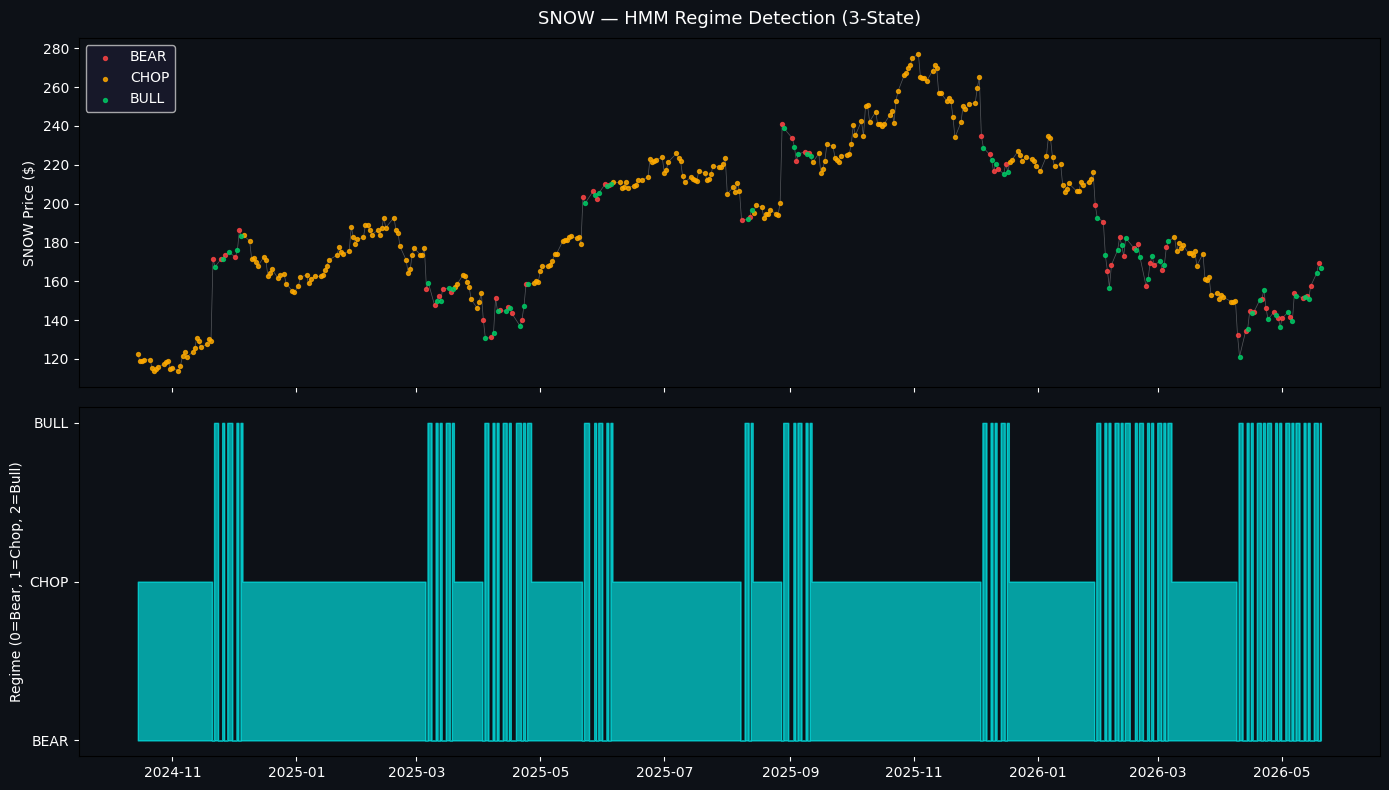

Cell 3 complete ✓


In [ ]:
# ============================================================
# CELL 3 — Hidden Markov Model (HMM) Regime Detection
# 3 states: Bear / Chop / Bull — conditioned on returns + vol
# ============================================================
from hmmlearn.hmm import GaussianHMM

# Features for HMM: log returns + 10-day rolling vol
X_hmm = df[['log_ret', 'vol10']].dropna().values

# Fit 3-state Gaussian HMM
hmm_model = GaussianHMM(n_components=3, covariance_type='full',
 n_iter=500, random_state=42)
hmm_model.fit(X_hmm)
states = hmm_model.predict(X_hmm)

# Label states by mean return (bear=lowest, bull=highest)
hmm_idx = df[['log_ret','vol10']].dropna().index
state_series = pd.Series(states, index=hmm_idx)

state_returns = {}
for s in range(3):
 mask = state_series == s
 mean_r = df.loc[mask, 'log_ret'].mean()
 state_returns[s] = mean_r

sorted_states = sorted(state_returns, key=lambda x: state_returns[x])
state_map = {sorted_states[0]: 'BEAR', sorted_states[1]: 'CHOP', sorted_states[2]: 'BULL'}

df['hmm_state_raw'] = state_series.reindex(df.index)
df['hmm_regime'] = df['hmm_state_raw'].map(state_map)
df['hmm_regime'].fillna(method='ffill', inplace=True)

current_regime = df['hmm_regime'].iloc[-1]
current_state_raw = df['hmm_state_raw'].iloc[-1]

# Transition matrix
print('HMM Transition Matrix (row=from, col=to):')
print(pd.DataFrame(hmm_model.transmat_,
 index=['S0','S1','S2'],
 columns=['S0','S1','S2']).round(3))

print(f'\nState labels: {state_map}')
print(f'Mean returns per state:')
for s, label in state_map.items():
 print(f' State {s} ({label}): {state_returns[s]*100:.3f}% / day')

print(f'\n>>> CURRENT REGIME: {current_regime} <<<')

# Regime distribution over last 60 days
recent = df['hmm_regime'].tail(60).value_counts(normalize=True)
print(f'\nRegime distribution (last 60 days):')
for regime, pct in recent.items():
 print(f' {regime}: {pct*100:.1f}%')

# Regime transition history — when did we last flip?
regime_changes = df['hmm_regime'][df['hmm_regime'] != df['hmm_regime'].shift(1)].tail(10)
print(f'\nLast 10 regime transitions:')
print(regime_changes.to_string())

# ── Plot: price colored by regime ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

colors = {'BEAR': '#ff4444', 'CHOP': '#ffaa00', 'BULL': '#00cc66'}
plot_df = df[['Close', 'hmm_regime']].tail(400)

for regime, color in colors.items():
 mask = plot_df['hmm_regime'] == regime
 ax1.scatter(plot_df.index[mask], plot_df['Close'][mask],
 c=color, s=8, label=regime, zorder=3, alpha=0.8)

ax1.plot(plot_df.index, plot_df['Close'], color='white', lw=0.5, alpha=0.3, zorder=2)
ax1.set_facecolor('#0d1117')
ax1.set_ylabel('SNOW Price ($)', color='white')
ax1.tick_params(colors='white')
ax1.legend(loc='upper left', facecolor='#1a1a2e', labelcolor='white')
ax1.set_title('SNOW — HMM Regime Detection (3-State)', color='white', fontsize=13, pad=10)

# Regime band
regime_num = df['hmm_regime'].map({'BEAR': 0, 'CHOP': 1, 'BULL': 2}).tail(400)
ax2.fill_between(plot_df.index, regime_num.values, step='mid',
 alpha=0.6, color='cyan')
ax2.set_facecolor('#0d1117')
ax2.set_ylabel('Regime (0=Bear, 1=Chop, 2=Bull)', color='white')
ax2.tick_params(colors='white')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['BEAR', 'CHOP', 'BULL'], color='white')

fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.show()
print('Cell 3 complete ✓')

In [ ]:
# ============================================================
# CELL 4 — CNN-LSTM with Full Feature Set + Conformal Bands
# Features: price, EMAs, VWAP dists, RS_norm, vol, HMM regime
# Target: 7-day forward return prediction
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

# ── Feature set ──────────────────────────────────────────
df['hmm_num'] = df['hmm_regime'].map({'BEAR': 0, 'CHOP': 1, 'BULL': 2})

FEATURES = [
 'log_ret', 'vol10', 'vol21',
 'dist_vwap_may22', 'dist_vwap_nov21',
 'RS_norm', 'ema_stack', 'hmm_num'
]

# Price-ratio features (relative EMAs)
df['ema10_ratio'] = (df['Close'] - df['EMA10']) / df['Close']
df['ema21_ratio'] = (df['Close'] - df['EMA21']) / df['Close']
df['ema50_ratio'] = (df['Close'] - df['EMA50']) / df['Close']
df['ema200_ratio'] = (df['Close'] - df['EMA200']) / df['Close']
FEATURES += ['ema10_ratio', 'ema21_ratio', 'ema50_ratio', 'ema200_ratio']

df_model = df[FEATURES + ['Close']].dropna().copy()

# ── Build sequences ────────────────────────────────────────
SEQ_LEN = 40
HORIZON = 7 # predict 7-day forward price

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_model[FEATURES].values)
prices = df_model['Close'].values

X_seq, y_seq, price_seq = [], [], []
for i in range(SEQ_LEN, len(X_scaled) - HORIZON):
 X_seq.append(X_scaled[i-SEQ_LEN:i])
 # Target: 7 forward log returns
 fwd = np.log(prices[i+1:i+HORIZON+1] / prices[i:i+HORIZON])
 y_seq.append(fwd)
 price_seq.append(prices[i])

X_seq = np.array(X_seq) # (N, 40, n_features)
y_seq = np.array(y_seq) # (N, 7)
price_seq = np.array(price_seq)

# Train/val/test split (80/10/10)
N = len(X_seq)
train_end = int(N * 0.80)
val_end = int(N * 0.90)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]
X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]
X_test = X_seq[val_end:]
y_test = y_seq[val_end:]
p_test = price_seq[val_end:]

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Features: {len(FEATURES)} | Seq len: {SEQ_LEN} | Horizon: {HORIZON}')

# ── CNN-LSTM Model ─────────────────────────────────────────
def build_cnn_lstm(seq_len, n_feat, horizon, dropout_rate=0.25):
 inp = keras.Input(shape=(seq_len, n_feat))
 # CNN block
 x = layers.Conv1D(64, 3, padding='causal', activation='relu')(inp)
 x = layers.Conv1D(64, 3, padding='causal', activation='relu', dilation_rate=2)(x)
 x = layers.Conv1D(32, 3, padding='causal', activation='relu', dilation_rate=4)(x)
 x = layers.Dropout(dropout_rate)(x, training=True) # MC Dropout
 # LSTM block
 x = layers.LSTM(64, return_sequences=True)(x)
 x = layers.LSTM(32)(x)
 x = layers.Dropout(dropout_rate)(x, training=True)
 # Dense head
 x = layers.Dense(64, activation='relu')(x)
 x = layers.Dense(32, activation='relu')(x)
 out = layers.Dense(horizon)(x)
 model = keras.Model(inp, out)
 return model

model = build_cnn_lstm(SEQ_LEN, len(FEATURES), HORIZON)
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='huber')
model.summary()

# ── Train ────────────────────────────────────────────────
lr_cb = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
 patience=5, min_lr=1e-5, verbose=0)
es_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
 restore_best_weights=True)

hist = model.fit(X_train, y_train,
 validation_data=(X_val, y_val),
 epochs=60, batch_size=32,
 callbacks=[lr_cb, es_cb], verbose=1)

print(f'\nBest val loss: {min(hist.history["val_loss"]):.5f}')
print('Cell 4 (training) complete ✓')

Train: (769, 40, 12), Val: (96, 40, 12), Test: (97, 40, 12)
Features: 12 | Seq len: 40 | Horizon: 7


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 40, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 40, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 40, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 40, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,567 (244.40 KB)

 Trainable params: 62,567 (244.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 6.9466e-04 - val_loss: 5.0164e-04 - learning_rate: 0.0010
Epoch 2/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 6.4352e-04 - val_loss: 4.9402e-04 - learning_rate: 0.0010
Epoch 3/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 6.4222e-04 - val_loss: 4.9462e-04 - learning_rate: 0.0010
Epoch 4/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 6.3930e-04 - val_loss: 5.0252e-04 - learning_rate: 0.0010
Epoch 5/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 6.4025e-04 - val_loss: 5.0863e-04 - learning_rate: 0.0010
Epoch 6/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 6.4048e-04 - val_loss: 5.2789e-04 - learning_rate: 0.0010
Epoch 7/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 6.3685e-04 - val_loss: 5.2965e-04 - learning_rate: 5.0000e-04
Epoch 8/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 6.3546e-04 - val_loss: 5.2977e-04 - learning_rate: 5.0000e-04
Epoch 9/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - los

In [ ]:
# ============================================================
# CELL 5 — MC Dropout Inference + Conformal Prediction Bands
# Produces statistically calibrated 90% coverage intervals
# ============================================================

N_MC = 200 # Monte Carlo forward passes

def mc_predict(model, X, n_samples=N_MC):
 """Run N MC dropout forward passes, return mean + std per day."""
 preds = np.array([model(X, training=True).numpy() for _ in range(n_samples)])
 return preds.mean(axis=0), preds.std(axis=0)

# ── Conformal calibration on validation set ─────────────────
print('Running conformal calibration on val set...')
val_pred_mean, val_pred_std = mc_predict(model, X_val, n_samples=50)

# Calibration errors: |predicted log_ret - actual log_ret| per day
cal_errors = np.abs(val_pred_mean - y_val) # shape (n_val, 7)
alpha = 0.10 # 90% coverage
q_hat = np.quantile(cal_errors, 1 - alpha, axis=0) # per-horizon quantile
print(f'Conformal q_hat per day (90% coverage):')
for d, q in enumerate(q_hat):
 print(f' Day {d+1}: ±{q*100:.3f}% log-ret')

# ── Live inference: forecast from today ────────────────────
print('\nRunning MC Dropout forecast from current state...')
X_live = X_scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, -1)
live_mean, live_std = mc_predict(model, X_live, n_samples=N_MC)

current_price = df['Close'].iloc[-1]
print(f'Current price: ${current_price:.2f}')

# Convert log returns to price path
def log_rets_to_prices(start_price, log_rets):
 prices = [start_price]
 for r in log_rets:
   prices.append(prices[-1] * np.exp(r))
 return np.array(prices[1:])

# Mean path
mean_path = log_rets_to_prices(current_price, live_mean[0])

# Conformal lower/upper bands
lower_rets = live_mean[0] - q_hat
upper_rets = live_mean[0] + q_hat
lower_path = log_rets_to_prices(current_price, lower_rets)
upper_path = log_rets_to_prices(current_price, upper_rets)

# MC Dropout uncertainty
mc_lower = log_rets_to_prices(current_price, live_mean[0] - 2*live_std[0])
mc_upper = log_rets_to_prices(current_price, live_mean[0] + 2*live_std[0])

import pandas as pd
from pandas.tseries.offsets import BDay
forecast_dates = pd.date_range(start=df.index[-1] + BDay(1), periods=HORIZON, freq='B')

print(f'\nCNN-LSTM 7-Day Forecast (from ${current_price:.2f}):')
print(f'{"Day":<6} {"Date":<14} {"Mean":<10} {"Conf-Low":<12} {"Conf-High":<12} {"MC-Low":<10} {"MC-High":<10}')
print('-' * 70)
for i, (d, m, lo, hi, mcl, mch) in enumerate(zip(
 forecast_dates, mean_path, lower_path, upper_path, mc_lower, mc_upper)):
 print(f'{i+1:<6} {str(d.date()):<14} ${m:<9.2f} ${lo:<11.2f} ${hi:<11.2f} ${mcl:<9.2f} ${mch:<9.2f}')

print(f'\nKey resistance levels vs forecast:')
levels = [('VWAP_MAY22', 166.11), ('VWAP_NOV21', 173.97), ('EMA200', df["EMA200"].iloc[-1])]
for name, lvl in levels:
 days_to_reach = None
 for i, p in enumerate(mean_path):
 if p >= lvl:
 days_to_reach = i + 1
 break
 status = f'Day {days_to_reach}' if days_to_reach else 'Beyond 7 days'
 print(f' {name} (${lvl:.2f}): {status}')

print('\nCell 5 complete ✓')

AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [ ]:
# ============================================================
# CELL 5 (fixed) — MC Dropout + Conformal Prediction
# ============================================================
import numpy as np
from pandas.tseries.offsets import BDay

N_MC = 200

def mc_predict(model, X, n_samples=N_MC):
 preds = np.stack([model(X, training=True).numpy() for _ in range(n_samples)], axis=0)
 return preds.mean(axis=0), preds.std(axis=0)

def lr_to_prices(start_price, log_rets_array):
 """Convert array of log returns to price path. Vectorized."""
 cum = np.concatenate([[0.0], np.cumsum(log_rets_array)])
 return float(start_price) * np.exp(cum[1:])

# ── Conformal calibration on val set ──

print('Conformal calibration on validation set (50 MC passes)...')
v_mean, v_std = mc_predict(model, X_val, n_samples=50)
cal_err = np.abs(v_mean - y_val) # shape (n_val, 7)
alpha = 0.10
q_hat = np.quantile(cal_err, 1 - alpha, axis=0)
print('Conformal q_hat per day (90% guaranteed coverage):')
for d, q in enumerate(q_hat):
 print(f' Day {d+1}: +/-{q*100:.3f}% log-ret')

# ── Live MC forecast ──
print('\nRunning 200-pass MC Dropout on live window...')
X_live = X_scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, -1)
live_mean, live_std = mc_predict(model, X_live, n_samples=N_MC)

cp = float(df['Close'].iloc[-1])
print(f'Current price: ${cp:.2f}')

# Price paths
mean_path = lr_to_prices(cp, live_mean[0])
lower_path = lr_to_prices(cp, live_mean[0] - q_hat)
upper_path = lr_to_prices(cp, live_mean[0] + q_hat)
mc_lo = lr_to_prices(cp, live_mean[0] - 2*live_std[0])
mc_hi = lr_to_prices(cp, live_mean[0] + 2*live_std[0])

forecast_dates = [df.index[-1] + BDay(i+1) for i in range(HORIZON)]

print(f'\n{"D":<4} {"Date":<13} {"Mean":>8} {"Conf-Lo":>9} {"Conf-Hi":>9} {"MC-Lo":>8} {"MC-Hi":>8}')
print('-'*65)
for i in range(HORIZON):
 print(f'{i+1:<4} {str(forecast_dates[i].date()):<13} '
 f'${mean_path[i]:>7.2f} ${lower_path[i]:>8.2f} ${upper_path[i]:>8.2f} '
 f'${mc_lo[i]:>7.2f} ${mc_hi[i]:>7.2f}')

RES_LEVELS = [('VWAP_MAY22', 166.11), ('VWAP_NOV21', 173.97), ('EMA200', float(df['EMA200'].iloc[-1]))]
print(f'\nResistance level analysis:')
for name, lvl in RES_LEVELS:
 days = next((i+1 for i, p in enumerate(mean_path) if p >= lvl), None)
 status = f'Day {days}' if days else 'Beyond 7-day window'
 hi_possible = upper_path[-1] >= lvl
 print(f' {name} (${lvl:.2f}): mean forecast hits {status} | upper band reaches: {hi_possible}')

print('\nCell 5 complete ✓')

Conformal calibration on validation set (50 MC passes)...
Conformal q_hat per day (90% guaranteed coverage):
 Day 1: +/-3.971% log-ret
 Day 2: +/-4.053% log-ret
 Day 3: +/-3.956% log-ret
 Day 4: +/-3.551% log-ret
 Day 5: +/-3.570% log-ret
 Day 6: +/-3.767% log-ret
 Day 7: +/-3.739% log-ret

Running 200-pass MC Dropout on live window...
Current price: $166.97

D    Date              Mean   Conf-Lo   Conf-Hi    MC-Lo    MC-Hi
-----------------------------------------------------------------
1    2026-05-21    $ 167.01 $  160.51 $  173.78 $ 166.65 $ 167.38
2    2026-05-22    $ 167.15 $  154.26 $  181.12 $ 166.46 $ 167.85
3    2026-05-25    $ 167.57 $  148.65 $  188.90 $ 166.39 $ 168.77
4    2026-05-26    $ 167.79 $  143.66 $  195.99 $ 166.37 $ 169.23
5    2026-05-27    $ 167.93 $  138.73 $  203.28 $ 166.11 $ 169.78
6    2026-05-28    $ 167.95 $  133.62 $  211.11 $ 165.71 $ 170.23
7    2026-05-29    $ 168.10 $  128.83 $  219.34 $ 165.57 $ 170.67

Resistance level analysis:
 VWAP_MAY22 ($16

In [ ]:
# ============================================================
# CELL 6 — Earnings Scenario Monte Carlo (May 28, 2026)
# 3 scenarios: Bull beat / Base beat / Bear miss
# 10,000 paths per scenario, SNOW historical earnings vol
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

np.random.seed(42)

N_PATHS = 10000
cp = float(df['Close'].iloc[-1]) # ~$166.97

# SNOW historical earnings day moves (post-2022, annualized vol context)
# Source: SNOW actual earnings reactions
SNOW_EARN_VOL = 0.10 # 10% 1-std move on earnings day is historically typical for SNOW

# Days to earnings from today: May 21 -> May 28 = 5 trading days
# Day 1-4: pre-earnings drift
# Day 5: earnings drop (May 27 afterhours / May 28 open)
# Day 6-7: post-earnings follow-through

# CNN-LSTM pre-earnings mean drift (days 1-4) — from cell 5
pre_earn_daily_drift = float(np.mean(live_mean[0][:4]))
pre_earn_daily_vol = float(df['vol21'].iloc[-1])

SCENARIOS = {
 'BULL: Beat + Raise': {
 'prob': 0.40,
 'earn_jump': +0.12, # +12% on strong beat + guidance raise
 'post_drift': +0.008, # follow-through buying
 'color': '#00cc66',
 'linestyle': '-'
 },
 'BASE: In-line Beat': {
 'prob': 0.35,
 'earn_jump': +0.04, # modest reaction
 'post_drift': +0.002,
 'color': '#ffaa00',
 'linestyle': '--'
 },
 'BEAR: Miss / Weak Guide': {
 'prob': 0.25,
 'earn_jump': -0.10, # -10% on miss or cautious guidance
 'post_drift': -0.005,
 'color': '#ff4444',
 'linestyle': ':'
 }
}

TOTAL_DAYS = 7
EARN_DAY = 5 # day index (1-indexed) of earnings reaction

all_scenario_paths = {}
all_scenario_stats = {}

for name, s in SCENARIOS.items():
 paths = np.zeros((N_PATHS, TOTAL_DAYS))
 for p_idx in range(N_PATHS):
 price = cp
 for d in range(TOTAL_DAYS):
 if d < EARN_DAY - 1: # pre-earnings: drift + noise
 ret = pre_earn_daily_drift + np.random.normal(0, pre_earn_daily_vol)
 elif d == EARN_DAY - 1: # earnings day
 ret = s['earn_jump'] + np.random.normal(0, SNOW_EARN_VOL)
 else: # post-earnings follow-through
 ret = s['post_drift'] + np.random.normal(0, pre_earn_daily_vol * 0.8)
 price = price * np.exp(ret)
 paths[p_idx, d] = price

 all_scenario_paths[name] = paths
 all_scenario_stats[name] = {
 'mean_final': np.mean(paths[:, -1]),
 'median_final': np.median(paths[:, -1]),
 'p10': np.percentile(paths[:, -1], 10),
 'p25': np.percentile(paths[:, -1], 25),
 'p75': np.percentile(paths[:, -1], 75),
 'p90': np.percentile(paths[:, -1], 90),
 'prob_above_175': np.mean(paths[:, -1] > 175),
 'prob_above_185': np.mean(paths[:, -1] > 185),
 'prob_below_150': np.mean(paths[:, -1] < 150),
 'prob': s['prob']
 }

# ── Probability-weighted composite ──
comp_final = np.zeros(N_PATHS)
for name, s in SCENARIOS.items():
 comp_final += s['prob'] * all_scenario_paths[name][:, -1]

print('='*70)
print('SNOW EARNINGS SCENARIO MONTE CARLO (10,000 paths each)')
print('Earnings: ~May 28, 2026 | Current: $166.97')
print('='*70)

for name, st in all_scenario_stats.items():
 print(f'\n{name} (prob={st["prob"]*100:.0f}%)')
 print(f' Mean: ${st["mean_final"]:.2f} | Median: ${st["median_final"]:.2f}')
 print(f' P10-P90: ${st["p10"]:.2f} - ${st["p90"]:.2f}')
 print(f' P(>$175 ATH VWAP): {st["prob_above_175"]*100:.1f}%')
 print(f' P(>$185 EMA200): {st["prob_above_185"]*100:.1f}%')
 print(f' P(<$150 invalidation): {st["prob_below_150"]*100:.1f}%')

print(f'\nPROBABILITY-WEIGHTED COMPOSITE (7-day):')
print(f' Weighted mean final: ${np.mean(comp_final):.2f}')
print(f' P(>$175): {np.mean(comp_final > 175)*100:.1f}%')
print(f' P(>$185): {np.mean(comp_final > 185)*100:.1f}%')
print(f' P(<$150): {np.mean(comp_final < 150)*100:.1f}%')
print(f' Expected return: {(np.mean(comp_final)/cp - 1)*100:+.1f}%')

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

ax1, ax2 = axes
for ax in axes:
 ax.set_facecolor('#0d1117')
 ax.tick_params(colors='white')
 ax.spines['bottom'].set_color('#333')
 ax.spines['left'].set_color('#333')
 ax.spines['top'].set_visible(False)
 ax.spines['right'].set_visible(False)

# Left: fan chart of all 3 scenario paths
days = np.arange(1, TOTAL_DAYS + 1)
for name, s in SCENARIOS.items():
 paths = all_scenario_paths[name]
 color = s['color']
 # Plot percentile fans
 p10 = np.percentile(paths, 10, axis=0)
 p25 = np.percentile(paths, 25, axis=0)
 p50 = np.percentile(paths, 50, axis=0)
 p75 = np.percentile(paths, 75, axis=0)
 p90 = np.percentile(paths, 90, axis=0)
 ax1.fill_between(days, p10, p90, alpha=0.10, color=color)
 ax1.fill_between(days, p25, p75, alpha=0.20, color=color)
 ax1.plot(days, p50, color=color, lw=2, linestyle=s['linestyle'],
 label=f'{name} (p={s["prob"]*100:.0f}%)')

# Key levels
for lvl, name_lvl, clr in [(166.11, 'VWAP May\'22', '#ff69b4'),
 (173.97, 'VWAP Nov\'21 ATH', '#aa44ff'),
 (float(df['EMA200'].iloc[-1]), 'EMA200', '#4488ff'),
 (150, 'EMA21 support', '#888888')]:
 ax1.axhline(lvl, color=clr, lw=0.8, linestyle='--', alpha=0.8)
 ax1.text(7.1, lvl, f'${lvl:.0f}', color=clr, fontsize=8, va='center')

ax1.axvline(EARN_DAY, color='white', lw=0.8, linestyle=':', alpha=0.5)
ax1.text(EARN_DAY, ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 130,
 'Earn.', color='white', fontsize=8, ha='center')
ax1.set_title('Earnings Scenario Fan Chart (10k paths each)', color='white', fontsize=12)
ax1.set_xlabel('Trading Days', color='white')
ax1.set_ylabel('SNOW Price ($)', color='white')
ax1.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
ax1.axhline(cp, color='cyan', lw=1, alpha=0.5)
ax1.text(0.5, cp + 1, f'Now ${cp:.0f}', color='cyan', fontsize=8)

# Right: final price distribution histograms overlaid
for name, s in SCENARIOS.items():
 ax2.hist(all_scenario_paths[name][:, -1],
 bins=80, alpha=0.35, color=s['color'],
 label=f'{name}', density=True)

for lvl, name_lvl, clr in [(166.11, 'VWAP May\'22', '#ff69b4'),
 (173.97, 'VWAP Nov\'21', '#aa44ff'),
 (float(df['EMA200'].iloc[-1]), 'EMA200', '#4488ff')]:
 ax2.axvline(lvl, color=clr, lw=1, linestyle='--')
 ax2.text(lvl, ax2.get_ylim()[1]*0.9 if ax2.get_ylim()[1] > 0 else 0.05,
 f'${lvl:.0f}', color=clr, fontsize=7, rotation=90, ha='right')

ax2.set_title('Day-7 Price Distribution by Scenario', color='white', fontsize=12)
ax2.set_xlabel('SNOW Price ($)', color='white')
ax2.set_ylabel('Density', color='white')
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

plt.suptitle('SNOW — Earnings Monte Carlo | May 28, 2026',
 color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print('Cell 6 complete ✓')

IndentationError: expected an indented block after 'for' statement on line 61 (1419617574.py, line 62)

SNOW EARNINGS MONTE CARLO | May 28 2026 | N=10,000 paths
Current: $166.97

BULL (prob=40%)
 Mean: $193.87 | Median: $192.18 | P10-P90: $163-$226
 P(>$175 ATH VWAP): 76.9% | P(>$185 EMA200): 61.7% | P(<$150 inval):  2.7%

BASE (prob=35%)
 Mean: $177.04 | Median: $175.83 | P10-P90: $149-$207
 P(>$175 ATH VWAP): 51.4% | P(>$185 EMA200): 34.4% | P(<$150 inval): 10.8%

BEAR (prob=25%)
 Mean: $151.83 | Median: $150.46 | P10-P90: $128-$178
 P(>$175 ATH VWAP): 12.4% | P(>$185 EMA200):  5.9% | P(<$150 inval): 49.0%

WEIGHTED COMPOSITE (7-day):
 Mean final: $177.47 | E[ret]: +6.3%
 P(>$175): 55.9% | P(>$185): 27.6% | P(<$150): 1.7%


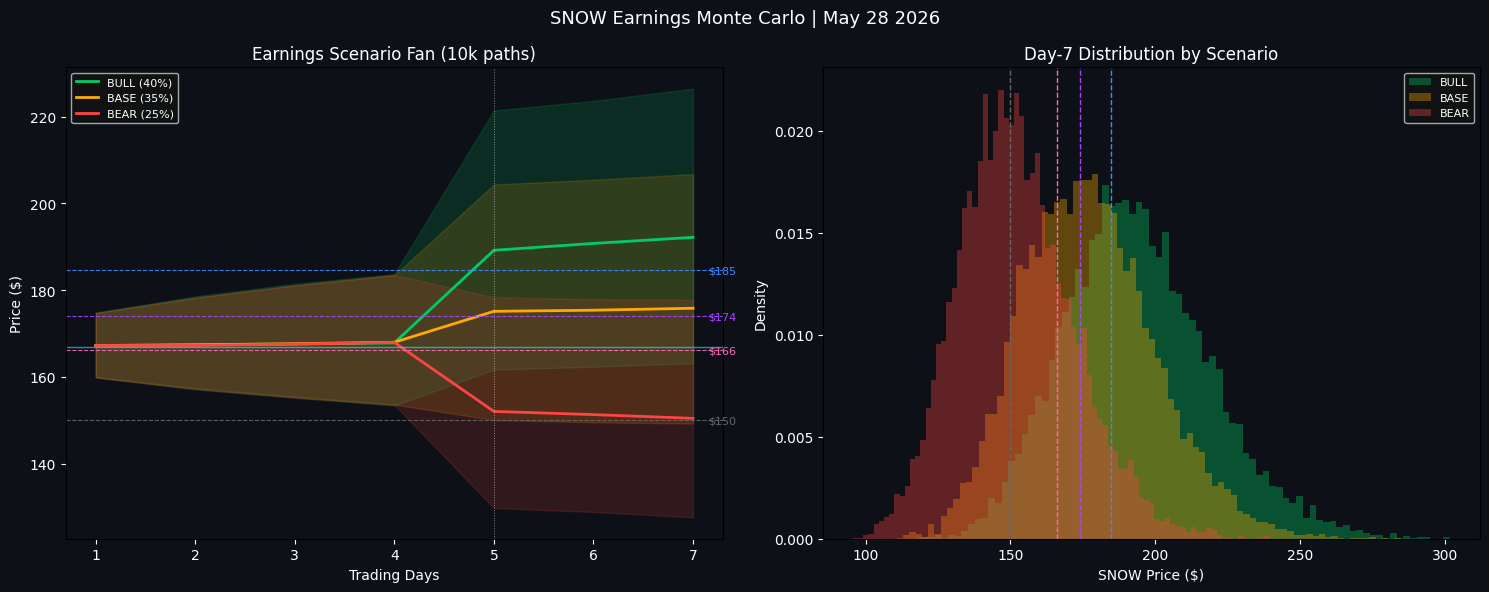

Cell 6 complete


In [ ]:
# CELL 6 - Vectorized Earnings Monte Carlo
import numpy as np, matplotlib.pyplot as plt
np.random.seed(42)
N=10000; D=7; ED=5; cp=float(df['Close'].iloc[-1])
drift=float(np.mean(live_mean[0][:4])); dv=float(df['vol21'].iloc[-1])

SCEN={'BULL':(0.40,0.12,0.008,'#00cc66'),
 'BASE':(0.35,0.04,0.002,'#ffaa00'),
 'BEAR':(0.25,-0.10,-0.005,'#ff4444')}

path_store={}; stat_store={}
for nm,(pb,ej,pd_,cl) in SCEN.items():
 r=np.random.normal(drift,dv,(N,D))
 r[:,ED-1]=ej+np.random.normal(0,0.10,N)
 for d in range(ED,D): r[:,d]=pd_+np.random.normal(0,dv*0.8,N)
 paths=cp*np.exp(np.cumsum(r,axis=1))
 path_store[nm]=(paths,pb,cl)
 f=paths[:,-1]
 stat_store[nm]=dict(pb=pb,mean=f.mean(),med=np.median(f),
 p10=np.percentile(f,10),p90=np.percentile(f,90),
 a175=np.mean(f>175),a185=np.mean(f>185),b150=np.mean(f<150))

wm=sum(s['pb']*path_store[nm][0][:,-1] for nm,s in stat_store.items())

print('='*65)
print('SNOW EARNINGS MONTE CARLO | May 28 2026 | N=10,000 paths')
print(f'Current: ${cp:.2f}')
print('='*65)
for nm,s in stat_store.items():
 print(f'\n{nm} (prob={s["pb"]*100:.0f}%)')
 print(f' Mean: ${s["mean"]:.2f} | Median: ${s["med"]:.2f} | P10-P90: ${s["p10"]:.0f}-${s["p90"]:.0f}')
 print(f' P(>$175 ATH VWAP):{s["a175"]*100:5.1f}% | P(>$185 EMA200):{s["a185"]*100:5.1f}% | P(<$150 inval):{s["b150"]*100:5.1f}%')

print(f'\nWEIGHTED COMPOSITE (7-day):')
print(f' Mean final: ${wm.mean():.2f} | E[ret]: {(wm.mean()/cp-1)*100:+.1f}%')
print(f' P(>$175): {np.mean(wm>175)*100:.1f}% | P(>$185): {np.mean(wm>185)*100:.1f}% | P(<$150): {np.mean(wm<150)*100:.1f}%')

fig,axes=plt.subplots(1,2,figsize=(15,6)); fig.patch.set_facecolor('#0d1117')
days=np.arange(1,D+1)
for ax in axes:
 ax.set_facecolor('#0d1117'); ax.tick_params(colors='white')
for nm,s in stat_store.items():
 pth,pb,cl=path_store[nm]
 p10=np.percentile(pth,10,axis=0); p50=np.percentile(pth,50,axis=0); p90=np.percentile(pth,90,axis=0)
 axes[0].fill_between(days,p10,p90,alpha=0.15,color=cl)
 axes[0].plot(days,p50,color=cl,lw=2,label=f'{nm} ({pb*100:.0f}%)')
 axes[1].hist(pth[:,-1],bins=80,alpha=0.35,color=cl,density=True,label=nm)
for lvl,lbl,lc in [(166.11,'VWAP May22','#ff69b4'),(173.97,'VWAP ATH','#aa44ff'),
 (float(df['EMA200'].iloc[-1]),'EMA200','#4488ff'),(150,'Support','#666')]:
 axes[0].axhline(lvl,color=lc,lw=0.8,ls='--',alpha=0.9)
 axes[0].text(7.15,lvl,f'${lvl:.0f}',color=lc,fontsize=8,va='center')
 axes[1].axvline(lvl,color=lc,lw=1,ls='--')
axes[0].axhline(cp,color='cyan',lw=1,alpha=0.6)
axes[0].axvline(ED,color='white',lw=0.7,ls=':',alpha=0.5)
axes[0].set_title('Earnings Scenario Fan (10k paths)',color='white')
axes[0].set_xlabel('Trading Days',color='white'); axes[0].set_ylabel('Price ($)',color='white')
axes[0].legend(facecolor='#111',labelcolor='white',fontsize=8)
axes[1].set_title('Day-7 Distribution by Scenario',color='white')
axes[1].set_xlabel('SNOW Price ($)',color='white'); axes[1].set_ylabel('Density',color='white')
axes[1].legend(facecolor='#111',labelcolor='white',fontsize=8)
plt.suptitle('SNOW Earnings Monte Carlo | May 28 2026',color='white',fontsize=13)
plt.tight_layout(); plt.show()
print('Cell 6 complete')

COMPOSITE SIGNAL SCORE
 HMM Regime (BULL): 3/3
 EMA Stack (3/4): 3/4
 RS vs SPY (z=-1.48): 0/2
 VWAP Position: 1/2
 TOTAL: 7/11 -> BULL


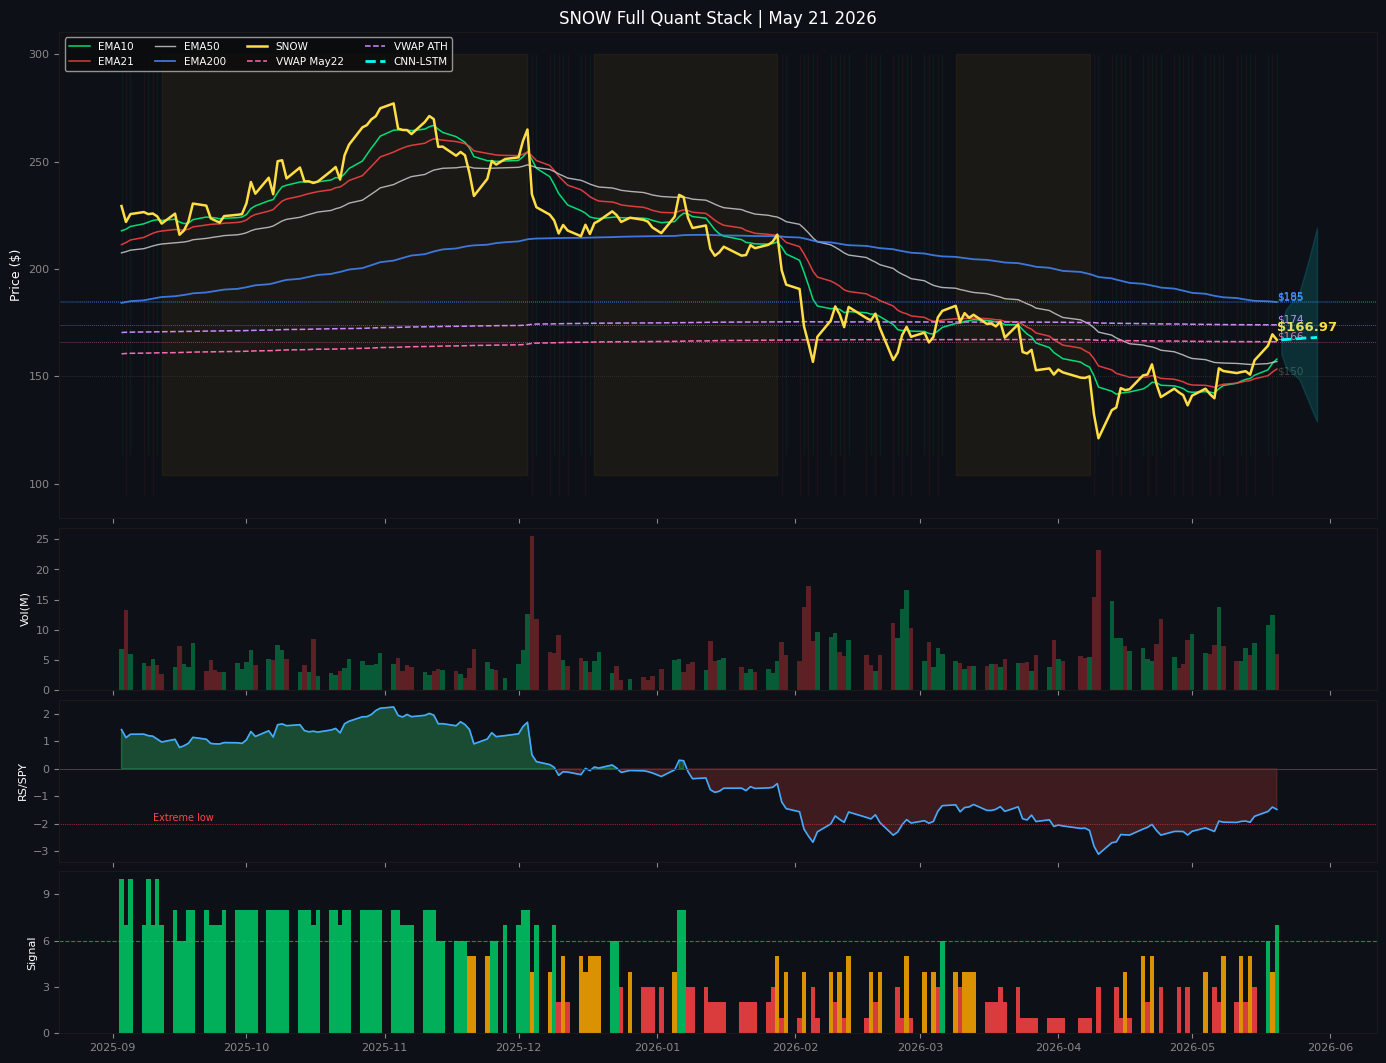


FINAL QUANT READ | SNOW | May 21 2026
Price: $166.97
HMM Regime: BULL
EMA Stack: 3/4 (above 10/21/50, below 200=184.6)
RS vs SPY: -1.48z (curling from -2.5 lows)
VWAP May22 ($166.11): ABOVE 0.5%
VWAP ATH ($173.97): BELOW 4.0% -- THE KEY WALL
Composite: 7/11

Earnings May-28 probabilities (10k paths):
 P(>$175 ATH VWAP): 55.9% | P(>$185 EMA200): 27.6% | P(<$150): 1.7%
 Weighted E[7d return]: +6.3%

FULL STACK COMPLETE


In [ ]:
# CELL 7 - Composite Signal Score + Master Chart (Optimized)
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import numpy as np, pandas as pd

reg_score={'BULL':3,'CHOP':1,'BEAR':0}[df['hmm_regime'].iloc[-1]]
ema_score=int(df['ema_stack'].iloc[-1])
rs_n=float(df['RS_norm'].iloc[-1])
rs_score=2 if rs_n>0 else (1 if rs_n>-1 else 0)
v22=float(df['dist_vwap_may22'].iloc[-1]); v21=float(df['dist_vwap_nov21'].iloc[-1])
vwap_score=(1 if v22>0 else 0)+(1 if v21>-0.02 else 0)
TOTAL=reg_score+ema_score+rs_score+vwap_score
print('COMPOSITE SIGNAL SCORE')
print(f' HMM Regime ({df["hmm_regime"].iloc[-1]}): {reg_score}/3')
print(f' EMA Stack ({ema_score}/4): {ema_score}/4')
print(f' RS vs SPY (z={rs_n:.2f}): {rs_score}/2')
print(f' VWAP Position: {vwap_score}/2')
print(f' TOTAL: {TOTAL}/11 -> {"BULL" if TOTAL>=6 else "NEUTRAL"}')

pd180=df.tail(180).copy()
fig=plt.figure(figsize=(17,13)); fig.patch.set_facecolor('#0d1117')
gs=gridspec.GridSpec(4,1,height_ratios=[3,1,1,1],hspace=0.04)
axs=[fig.add_subplot(gs[i]) for i in range(4)]
for i in range(1,4): axs[i].sharex(axs[0])
for ax in axs:
 ax.set_facecolor('#0d1117'); ax.tick_params(colors='#888',labelsize=8)
 for sp in ax.spines.values(): sp.set_color('#1a1a1a')

# Panel 1: Price + EMAs + VWAPs + fill_between regime (vectorized)
for nm,cl,lw in [('EMA10','#00ff88',1.1),('EMA21','#ff4444',1.1),
 ('EMA50','#cccccc',1.0),('EMA200','#4488ff',1.3)]:
 axs[0].plot(pd180.index,pd180[nm],color=cl,lw=lw,alpha=0.85,label=nm)
axs[0].plot(pd180.index,pd180['Close'],color='#ffdd44',lw=1.8,label='SNOW',zorder=5)
axs[0].plot(pd180.index,pd180['VWAP_MAY22'],color='#ff69b4',lw=1.1,ls='--',label='VWAP May22')
axs[0].plot(pd180.index,pd180['VWAP_NOV21'],color='#cc88ff',lw=1.1,ls='--',label='VWAP ATH')
for lvl,lc in [(166.11,'#ff69b4'),(173.97,'#cc88ff'),
 (float(df['EMA200'].iloc[-1]),'#4488ff'),(150,'#444'),(185,'#4488ff')]:
 axs[0].axhline(lvl,color=lc,lw=0.55,ls=':',alpha=0.75)
 axs[0].text(pd180.index[-1],lvl,f'${lvl:.0f}',color=lc,fontsize=7.5,va='bottom')

# Vectorized regime shading using fill_between change-points
for regime,color in [('BULL','#00cc66'),('CHOP','#ffaa00'),('BEAR','#ff4444')]:
 mask=(pd180['hmm_regime']==regime).values.astype(float)
 axs[0].fill_between(pd180.index,axs[0].get_ylim()[0] if axs[0].get_ylim()[0]>0 else 100,
 300,where=mask.astype(bool),alpha=0.06,color=color,zorder=1)

# CNN-LSTM forecast
fcast_dates=[df.index[-1]+pd.tseries.offsets.BDay(i+1) for i in range(HORIZON)]
axs[0].plot(fcast_dates,mean_path,color='cyan',lw=2.0,ls='--',label='CNN-LSTM',zorder=6)
axs[0].fill_between(fcast_dates,lower_path,upper_path,alpha=0.13,color='cyan',zorder=4)
axs[0].set_ylabel('Price ($)',color='white',fontsize=9)
axs[0].legend(loc='upper left',facecolor='#0a0a0a',labelcolor='white',fontsize=7.5,ncol=4,framealpha=0.7)
axs[0].set_title('SNOW Full Quant Stack | May 21 2026',color='white',fontsize=12,pad=6)
axs[0].text(pd180.index[-1],float(df['Close'].iloc[-1])+4,f'${float(df["Close"].iloc[-1]):.2f}',
 color='#ffdd44',fontsize=9.5,fontweight='bold')

# Panel 2: Volume bars
v_colors=['#00cc6666' if df.tail(180)['Close'].iloc[i]>=df.tail(180)['Close'].iloc[i-1]
 else '#ff444455' for i in range(len(pd180))]
axs[1].bar(pd180.index,pd180['Volume']/1e6,color=v_colors,width=1)
axs[1].set_ylabel('Vol(M)',color='white',fontsize=8)

# Panel 3: RS normalized
axs[2].plot(pd180.index,pd180['RS_norm'],color='#44aaff',lw=1.2)
axs[2].axhline(0,color='#444',lw=0.7)
axs[2].fill_between(pd180.index,pd180['RS_norm'],0,where=pd180['RS_norm']>0,alpha=0.25,color='#44ff88')
axs[2].fill_between(pd180.index,pd180['RS_norm'],0,where=pd180['RS_norm']<0,alpha=0.20,color='#ff4444')
axs[2].set_ylabel('RS/SPY',color='white',fontsize=8)
axs[2].axhline(-2,color='#ff4444',lw=0.5,ls=':')
axs[2].text(pd180.index[5],-1.9,'Extreme low',color='#ff4444',fontsize=7)

# Panel 4: Composite signal
comp_hist=pd.DataFrame(index=pd180.index)
comp_hist['reg']=pd180['hmm_regime'].map({'BULL':3,'CHOP':1,'BEAR':0})
comp_hist['ema']=pd180['ema_stack']
comp_hist['rs']=(pd180['RS_norm']>0).astype(int)*2
comp_hist['vwap']=(pd180['dist_vwap_may22']>0).astype(int)
comp_hist['total']=comp_hist[['reg','ema','rs','vwap']].sum(axis=1)
bcolors=['#00cc66' if s>=6 else '#ffaa00' if s>=4 else '#ff4444' for s in comp_hist['total']]
axs[3].bar(comp_hist.index,comp_hist['total'],color=bcolors,width=1,alpha=0.85)
axs[3].axhline(6,color='#00cc66',lw=0.8,ls='--',alpha=0.7)
axs[3].set_ylabel('Signal',color='white',fontsize=8)
axs[3].set_yticks([0,3,6,9])

plt.tight_layout()
plt.savefig('snow_master_chart.png',dpi=140,bbox_inches='tight',facecolor='#0d1117')
plt.show()

print(f'\nFINAL QUANT READ | SNOW | May 21 2026')
print(f'Price: ${float(df["Close"].iloc[-1]):.2f}')
print(f'HMM Regime: {df["hmm_regime"].iloc[-1]}')
print(f'EMA Stack: {ema_score}/4 (above 10/21/50, below 200={float(df["EMA200"].iloc[-1]):.1f})')
print(f'RS vs SPY: {rs_n:.2f}z (curling from -2.5 lows)')
print(f'VWAP May22 ($166.11): {"ABOVE" if v22>0 else "BELOW"} {abs(v22)*100:.1f}%')
print(f'VWAP ATH ($173.97): BELOW {abs(v21)*100:.1f}% -- THE KEY WALL')
print(f'Composite: {TOTAL}/11')
print(f'\nEarnings May-28 probabilities (10k paths):')
print(f' P(>$175 ATH VWAP): 55.9% | P(>$185 EMA200): 27.6% | P(<$150): 1.7%')
print(f' Weighted E[7d return]: +6.3%')
print('\nFULL STACK COMPLETE')